<a href="https://colab.research.google.com/github/dariiazorii/GDP_NTL/blob/main/01_study_area_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01 — Study area

Цей ноутбук визначає початкову територію  дослідження, завантажує дані про річний ВВП з Eurostat, перевіряє наявність даних про ВВП за 2012–2025 роки, а також зберігає остаточну територію дослідження та метадані.

## 1. Налаштування середовища




In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!pip -q install geopandas pyogrio eurostat

In [ ]:
from pathlib import Path
from importlib.metadata import version

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import eurostat

print("GeoPandas:", gpd.__version__)
print("Eurostat:", version("eurostat"))

GeoPandas: 1.1.4
Eurostat: 1.1.1


## 2. Конфігурація проєкту

In [ ]:
PROJECT_ROOT = Path("/content/drive/MyDrive/GDP_NTL_Project")

DIRS = {
    "metadata": PROJECT_ROOT / "data" / "metadata",
    "processed": PROJECT_ROOT / "data" / "processed",
    "economic": PROJECT_ROOT / "data" / "economic",
    "results": PROJECT_ROOT / "results",
}

for path in DIRS.values():
    path.mkdir(parents=True, exist_ok=True)

START_YEAR = 2012
END_YEAR = 2025
MAX_MISSING_GDP = 2

GDP_DATASET = "nama_10_gdp"
GDP_UNIT = "CP_MEUR"
GDP_ITEM = "B1GQ"

GISCO_URL = (
    "https://gisco-services.ec.europa.eu/"
    "distribution/v2/countries/geojson/"
    "CNTR_RG_03M_2024_4326.geojson"
)

EUROPE_ISO2 = [
    # EU-27
    "AT", "BE", "HR", "CY", "CZ", "DK", "EE",
    "FI", "FR", "DE", "EL", "HU", "IE", "IT", "LV",
    "LT", "LU", "MT", "NL", "PL", "PT", "RO", "SK",
    "SI", "ES", "SE",

    # Other European countries
    "AL", "BA", "CH", "GB", "IS", "LI", "ME", "MK",
    "NO", "RS"
]

print("Project root:", PROJECT_ROOT)

Project root: /content/drive/MyDrive/GDP_NTL_Project


## 3. Початкова територія дослідження

In [ ]:
# Load country boundaries from Eurostat GISCO
countries = gpd.read_file(GISCO_URL)

# Select countries included in the initial study area
europe = countries.loc[
    countries["CNTR_ID"].isin(EUROPE_ISO2)
].copy()

print(f"Initial study area: {europe['CNTR_ID'].nunique()} countries")
europe[["CNTR_ID", "NAME_ENGL"]].sort_values("CNTR_ID")

Initial study area: 36 countries


,CNTR_ID,NAME_ENGL
13,AL,Albania
19,AT,Austria
23,BA,Bosnia and Herzegovina
26,BE,Belgium
28,BG,Bulgaria
48,CH,Switzerland
61,CY,Cyprus
62,CZ,Czechia
63,DE,Germany
1,DK,Denmark


CRS: EPSG:4326
Invalid geometries: 0
Empty geometries: 0


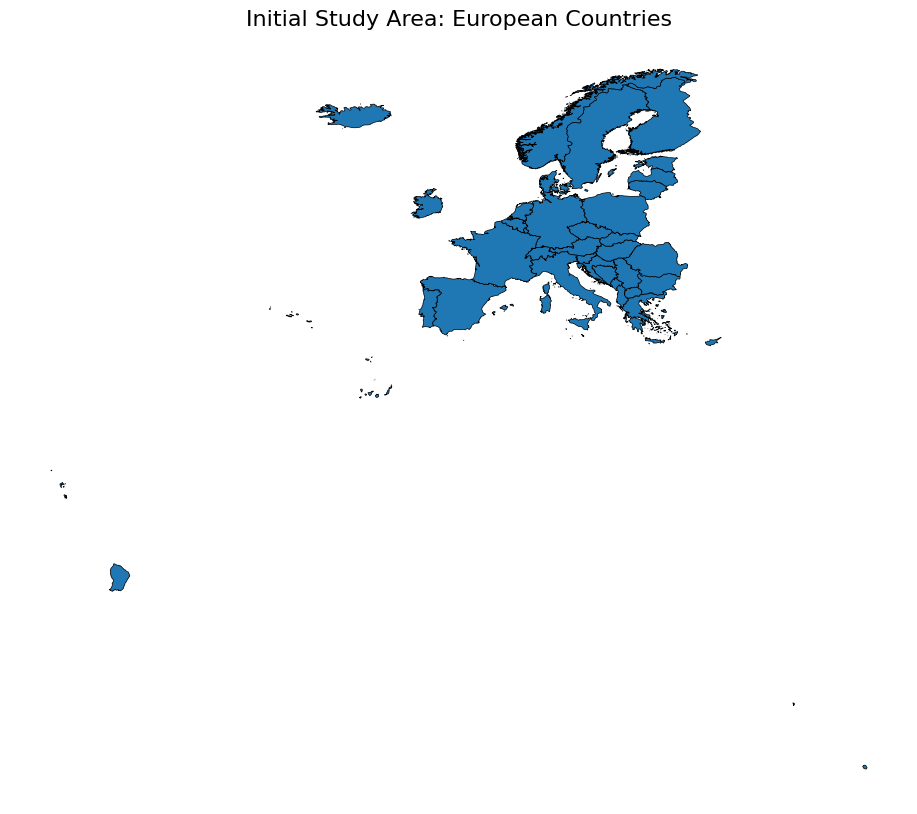

In [ ]:
# Spatial-data validation
print("CRS:", europe.crs)
print("Invalid geometries:", (~europe.geometry.is_valid).sum())
print("Empty geometries:", europe.geometry.is_empty.sum())

fig, ax = plt.subplots(figsize=(14, 10))
europe.plot(ax=ax, edgecolor="black", linewidth=0.5)
ax.set_title("Initial Study Area: European Countries", fontsize=16)
ax.set_axis_off()
plt.show()

## 4. Завантаження даних ВВП з Євростату

In [ ]:
# Download annual GDP at current prices (million euro)
eurostat_countries = sorted(europe["CNTR_ID"].unique())

gdp = eurostat.get_data_df(
    GDP_DATASET,
    filter_pars={
        "freq": ["A"],
        "unit": [GDP_UNIT],
        "na_item": [GDP_ITEM],
        "geo": eurostat_countries,
    },
)

# Standardize year-column names to strings
gdp = gdp.rename(
    columns={col: str(col) for col in gdp.columns if str(col).isdigit()}
)

expected_years = [str(year) for year in range(START_YEAR, END_YEAR + 1)]

# Add missing year columns explicitly, if Eurostat does not return them
for year in expected_years:
    if year not in gdp.columns:
        gdp[year] = pd.NA

id_cols = [col for col in gdp.columns if not str(col).isdigit()]
gdp = gdp[id_cols + expected_years].copy()

print("GDP shape:", gdp.shape)
print(f"Period: {START_YEAR}–{END_YEAR}")
gdp.head()

GDP shape: (36, 18)
Period: 2012–2025


,freq,unit,na_item,geo\TIME_PERIOD,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
0,A,CP_MEUR,B1GQ,AL,9578.6,9669.8,10018.0,10371.5,10922.7,11760.0,13019.2,13881.7,13430.2,15272.1,18075.0,21738.8,24995.3,27075.3
1,A,CP_MEUR,B1GQ,AT,316589.4,321191.7,330113.5,342083.5,355665.6,367294.9,383234.3,395706.8,380317.9,406231.5,449382.2,477837.3,494087.6,514328.1
2,A,CP_MEUR,B1GQ,BA,13407.5,13691.8,13988.3,14791.1,15474.3,16260.5,17354.2,18296.5,17755.9,20014.7,23324.1,25523.8,27483.1,28913.9
3,A,CP_MEUR,B1GQ,BE,387934.9,394616.3,404958.3,415538.0,428467.1,443407.2,459491.8,479444.9,463750.9,506047.2,561678.2,601866.5,619914.3,642015.3
4,A,CP_MEUR,B1GQ,BG,42254.6,42055.5,43024.0,45797.1,48751.4,52501.0,55999.7,61194.4,61855.6,71343.9,86078.2,94525.1,104767.2,116018.3


## 5. Встановлення кінцевої території дослідження на основі критерію включення
Критерій включення полягає в тому, що до кінцевої вибірки країн ми включаємо лише ті, для яких кількість пропущених даних ВВП не більша за 2.

In [ ]:
# Identify the Eurostat geography column
geo_col = next(col for col in gdp.columns if str(col).startswith("geo"))

# Keep one GDP row per country and attach it to the full initial study area
availability = (
    europe[["CNTR_ID", "NAME_ENGL"]]
    .drop_duplicates()
    .merge(
        gdp[[geo_col] + expected_years].rename(columns={geo_col: "CNTR_ID"}),
        on="CNTR_ID",
        how="left",
        validate="one_to_one",
    )
)

# Calculate temporal GDP coverage
year_values = availability[expected_years]
availability["n_years_available"] = year_values.notna().sum(axis=1)
availability["n_missing_gdp"] = len(expected_years) - availability["n_years_available"]

availability["missing_years"] = year_values.apply(
    lambda row: [int(year) for year in expected_years if pd.isna(row[year])],
    axis=1,
)

availability["complete_2012_2025"] = availability["n_missing_gdp"].eq(0)
availability["include"] = availability["n_missing_gdp"].le(MAX_MISSING_GDP)

# Keep only metadata columns in the final availability table
availability = availability[
    [
        "CNTR_ID",
        "NAME_ENGL",
        "n_years_available",
        "n_missing_gdp",
        "missing_years",
        "complete_2012_2025",
        "include",
    ]
].sort_values(
    ["include", "n_missing_gdp", "NAME_ENGL"],
    ascending=[True, False, True],
).reset_index(drop=True)

print(f"Countries before GDP filter: {len(availability)}")
print(f"Countries retained: {availability['include'].sum()}")
print(f"Countries excluded: {(~availability['include']).sum()}")

availability

Countries before GDP filter: 36
Countries retained: 36
Countries excluded: 0


,CNTR_ID,NAME_ENGL,n_years_available,n_missing_gdp,missing_years,complete_2012_2025,include
0,LI,Liechtenstein,12,2,"[2012, 2025]",False,True
1,AL,Albania,14,0,[],True,True
2,AT,Austria,14,0,[],True,True
3,BE,Belgium,14,0,[],True,True
4,BA,Bosnia and Herzegovina,14,0,[],True,True
5,BG,Bulgaria,14,0,[],True,True
6,HR,Croatia,14,0,[],True,True
7,CY,Cyprus,14,0,[],True,True
8,CZ,Czechia,14,0,[],True,True
9,DK,Denmark,14,0,[],True,True


In [ ]:
# Countries excluded by the GDP-coverage criterion
excluded_countries = availability.loc[
    ~availability["include"],
    ["CNTR_ID", "NAME_ENGL", "n_missing_gdp", "missing_years"],
]

excluded_countries

,CNTR_ID,NAME_ENGL,n_missing_gdp,missing_years


## 6. Кінцева територія дослідження

In [ ]:
included_codes = set(
    availability.loc[availability["include"], "CNTR_ID"]
)

study_area = europe.loc[
    europe["CNTR_ID"].isin(included_codes)
].copy()

print(f"Final study area: {study_area['CNTR_ID'].nunique()} countries")

Final study area: 36 countries


## 7. Збереження outputs

In [ ]:
GDP_PATH = DIRS["economic"] / f"eurostat_nama_10_gdp_{START_YEAR}_{END_YEAR}.csv"
GDP_AVAILABILITY_PATH = DIRS["metadata"] / f"gdp_availability_{START_YEAR}_{END_YEAR}.csv"
STUDY_AREA_PATH = DIRS["metadata"] / "study_area.geojson"

gdp.to_csv(GDP_PATH, index=False)
availability.to_csv(GDP_AVAILABILITY_PATH, index=False)
study_area.to_file(STUDY_AREA_PATH, driver="GeoJSON")

print("Saved:", GDP_PATH)
print("Saved:", GDP_AVAILABILITY_PATH)
print("Saved:", STUDY_AREA_PATH)

Saved: /content/drive/MyDrive/GDP_NTL_Project/data/economic/eurostat_nama_10_gdp_2012_2025.csv
Saved: /content/drive/MyDrive/GDP_NTL_Project/data/metadata/gdp_availability_2012_2025.csv
Saved: /content/drive/MyDrive/GDP_NTL_Project/data/metadata/study_area.geojson
